(<Figure size 2000x2000 with 2 Axes>, <WCSAxes: >)

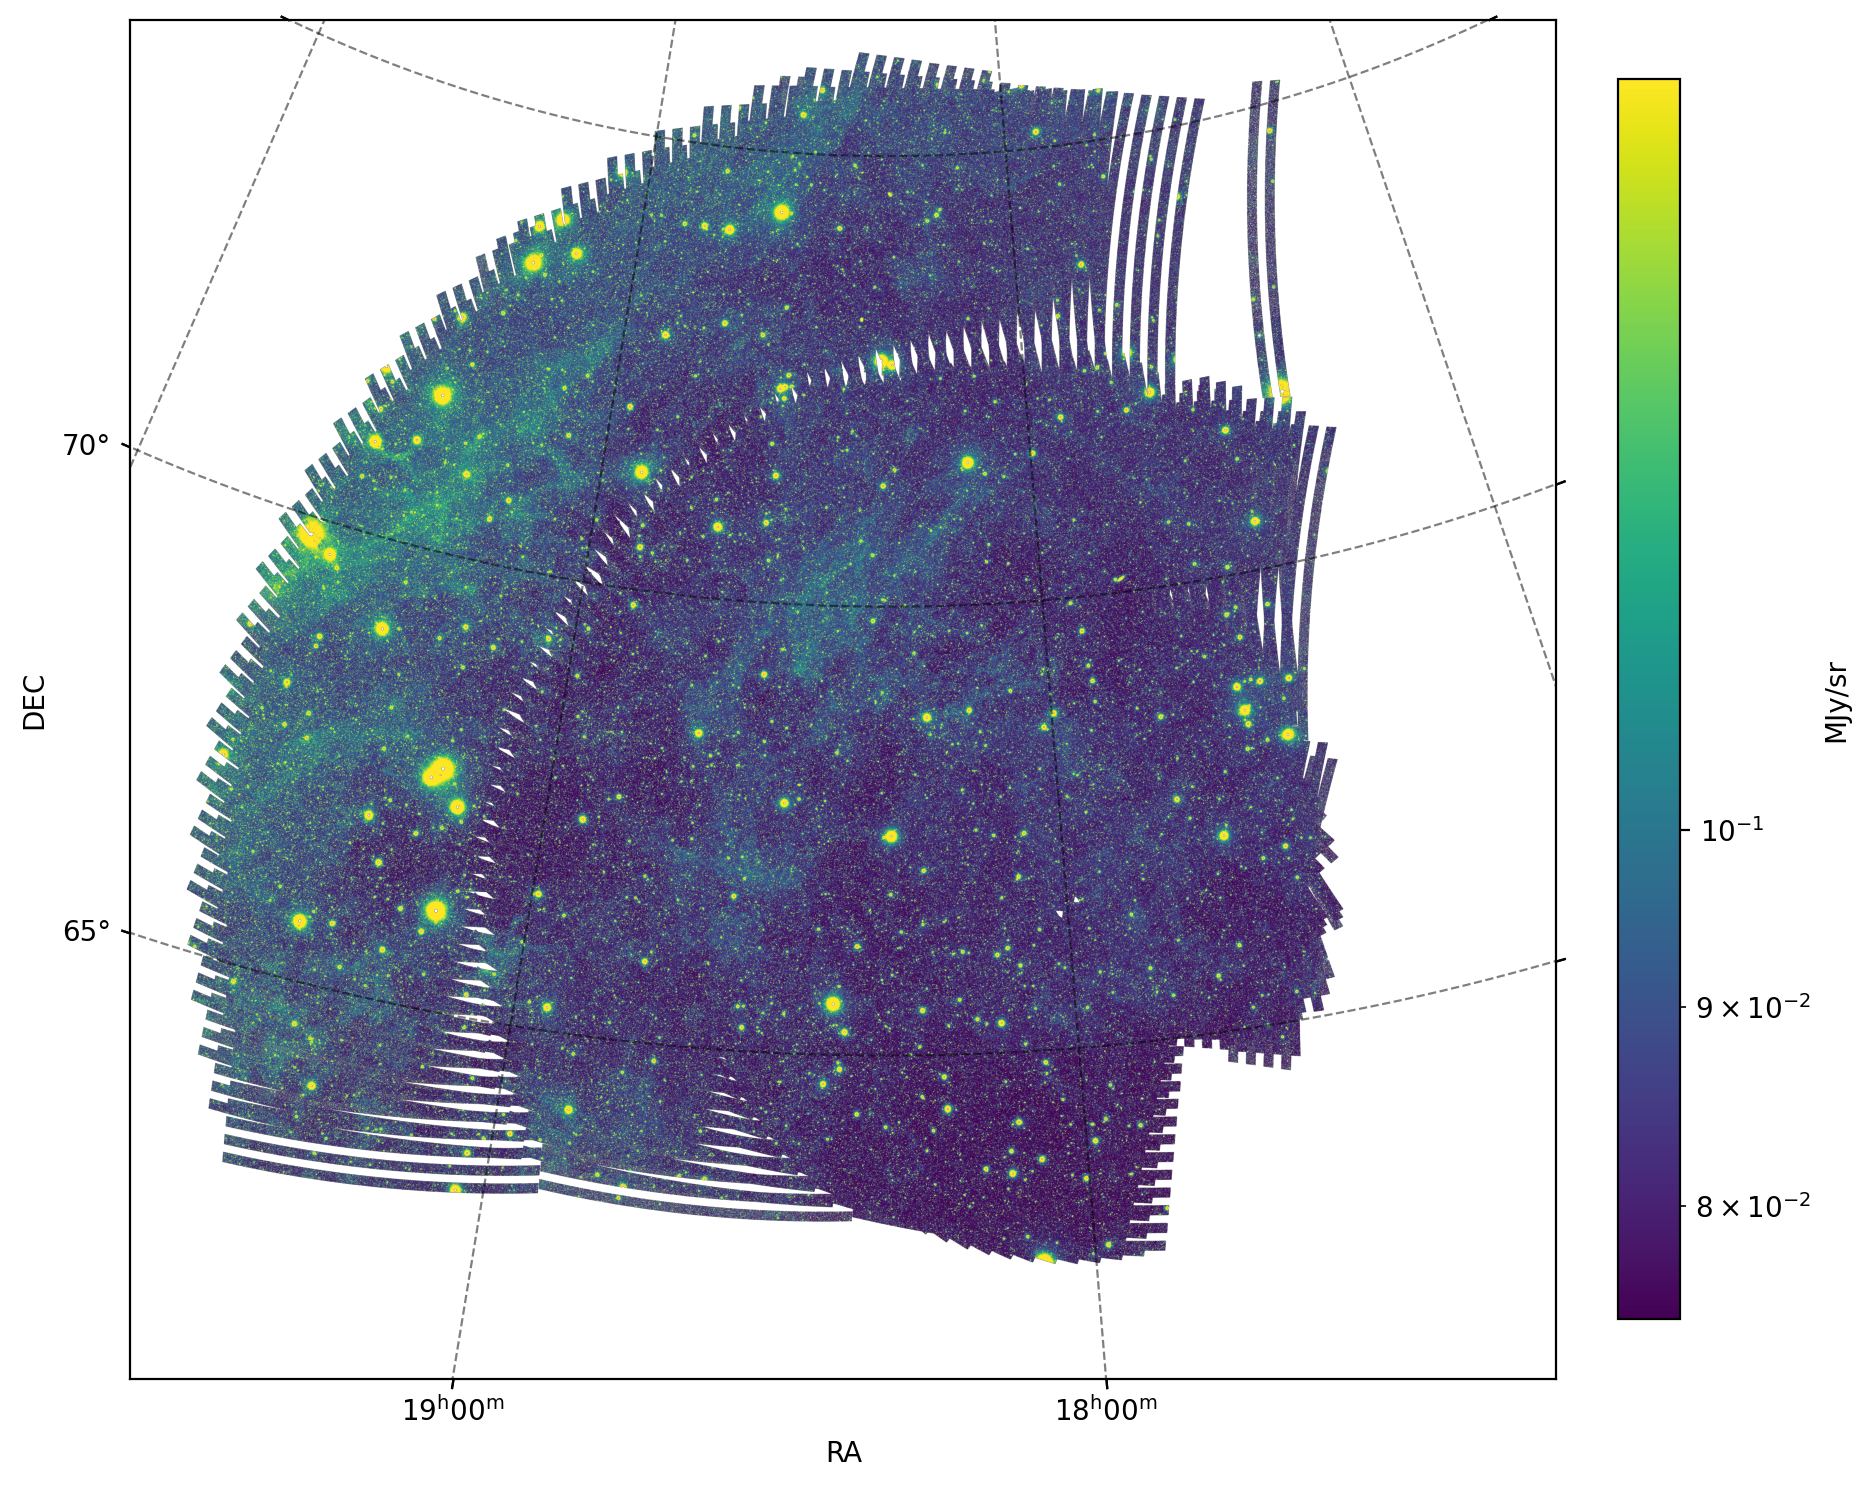

In [2]:
#Direct copy paste of thomas's code
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy.io import fits
from astropy.wcs import WCS
import h5py

def plot_map(map, wcs=None, lowp=0.5, highp=95, fig=None, ax=None, colorbar=True, low=None, high=None, cmap='viridis', norm=LogNorm,
            cbar_label='MJy/sr'):
    if low is None or high is None:
        high, low = np.nanpercentile(map[map>0], [highp, lowp])
    if fig is None:
        fig = plt.figure(figsize=(10, 10), dpi=200)
    if ax is None:
        ax = fig.add_subplot(111, projection=wcs)
    if norm is LogNorm:
        im = ax.imshow(map, norm=LogNorm(vmin=low, vmax=high), origin='lower', cmap=cmap)
    else:
        im = ax.imshow(map, vmin=low, vmax=high, origin='lower', cmap=cmap)

    if wcs is not None:
        # Explicitly set axis labels
        ax.coords['ra'].set_axislabel('RA')
        ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
        ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
        ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
        ax.coords['dec'].set_axislabel('DEC')
        ax.grid(color='black', linestyle='--', alpha=0.5)

    if colorbar:
        cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.040, pad=0.04)
        cbar.set_label(cbar_label)
    return fig, ax
run_dir = '/mnt/md124/thomasli/selfcal/outputs/nep_det4_6p2arcsec/'

mapname = 'mosaic_34channels_D4_PAH_subchannel225-235_unnormoffsets_noweight'
# mapname = 'mosaic_34channels_D4_Ch24_unnormoffsets_widecal'
aliph_path = os.path.join(run_dir, 'mosaic', mapname + '.fits')
wcs = WCS(fits.open(aliph_path)[5].header)
aliph_map = fits.open(aliph_path)[5].data
aliph_mask = fits.open(aliph_path)[6].data > 0

chunk_valid_mask = np.zeros(342)
chunk_valid_mask[224:237] = 1

aliph_cal_path = os.path.join(run_dir, 'calibration', mapname.replace('mosaic', 'cal') + '.h5')
with h5py.File(aliph_cal_path, 'r') as file:
    cal_offsets = file['O'][()]
mean_offsets = np.mean(cal_offsets[:,chunk_valid_mask.astype(bool)])
aliph_map[aliph_mask] += mean_offsets

plot_map(aliph_map, wcs=wcs, lowp=5, highp=95, cmap='viridis', norm=LogNorm)